# Recommendation Engine / System
## Proyecto: Recomendador de Repositorios de Github
### Usaremos Collaborative Filtering
Artículo completo en https://www.aprendemachinelearning.com/sistemas-de-recomendacion/

In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import sklearn

In [2]:
df_users = pd.read_csv("https://github.com/palasatenea66/DATASETS/raw/main/users.csv")
df_repos = pd.read_csv("https://github.com/palasatenea66/DATASETS/raw/main/repos.csv")
df_ratings = pd.read_csv("https://github.com/palasatenea66/DATASETS/raw/main/ratings.csv")

In [3]:
df_users

,userId,username,name
0,1,iris9112,Isabel Ruiz Buriticá
1,2,dianaclarke,Diana
2,3,nateprewitt,Nate Prewitt
3,4,oldani,Ordanis Sanchez
4,5,waflessnet,waflessnet
5,6,luisbalru,Luis Balderas Ruiz
6,7,elswork,elswork
7,8,l3s777,l3s777
8,9,camiloyate09,Camilo Yate
9,10,josmig,José Miguel Pantigoso


In [4]:
df_repos

,repoId,title,categories,stars
0,1,airbnb / javascript,completar,NaN
1,2,kamranahmedse / developer-roadmap,Roadmap to becoming a web developer in 2019,85800.0
2,3,microsoft / vscode,Visual Studio Code,80855.0
3,4,torvalds / linux,Linux kernel source tree,78761.0
4,5,ytdl-org / youtube-dl,Command-line program to download videos from Y...,53909.0
...,...,...,...,...
162,163,OmkarPathak / pygorithm,A Python module for learning all major algorithms,3743.0
163,164,MaximAbramchuck / awesome-interview-questions,A curated awesome list of lists of interview q...,28689.0
164,165,nodejs / node,Node.js JavaScript runtime,63397.0
165,166,OWASP / CheatSheetSeries,The OWASP Cheat Sheet Series was created to pr...,7793.0


In [5]:
df_ratings

,userId,repoId,rating
0,1,1,2
1,1,2,3
2,1,3,4
3,1,4,5
4,1,5,3
...,...,...,...
319,30,118,3
320,30,156,2
321,30,162,2
322,30,125,2


In [6]:
df_ratings[df_ratings['repoId']==4]

,userId,repoId,rating
3,1,4,5
56,5,4,5
95,10,4,5
219,21,4,5
306,30,4,5


In [7]:
n_users = df_ratings.userId.unique().shape[0]
n_items = df_ratings.repoId.unique().shape[0]
print (str(n_users) + ' users')
print (str(n_items) + ' items')

30 users
167 items


In [8]:
df_ratings['rating'].unique()

array([2, 3, 4, 5, 1, 8, 6, 7])

(array([94., 62., 66., 28., 40., 12., 14.,  8.]),
 array([1.   , 1.875, 2.75 , 3.625, 4.5  , 5.375, 6.25 , 7.125, 8.   ]),
 <BarContainer object of 8 artists>)

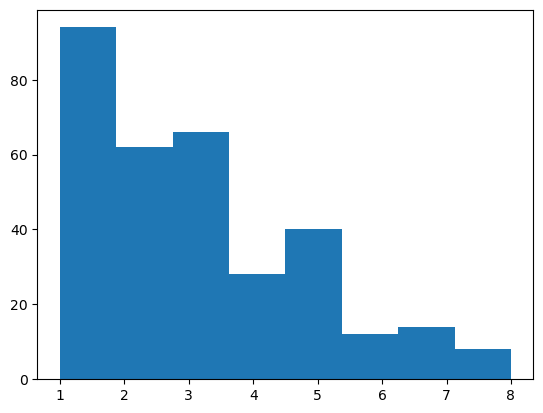

In [9]:
plt.hist(df_ratings.rating,bins=8)

In [ ]:
# Esa línea de código hace un conteo de cuántos usuarios calificaron con cada valor de rating
df_ratings.groupby(["rating"])["userId"].count()

rating
1    94
2    62
3    66
4    28
5    40
6    12
7    14
8     8
Name: userId, dtype: int64

In [11]:
df_ratings[df_ratings['rating']==7]

,userId,repoId,rating
68,6,62,7
69,7,62,7
70,7,63,7
79,8,63,7
96,10,62,7
104,11,63,7
105,11,62,7
128,14,62,7
137,15,62,7
182,18,62,7


(array([94., 31., 22.,  7.,  8.,  2.,  2.,  1.]),
 array([1.   , 1.875, 2.75 , 3.625, 4.5  , 5.375, 6.25 , 7.125, 8.   ]),
 <BarContainer object of 8 artists>)

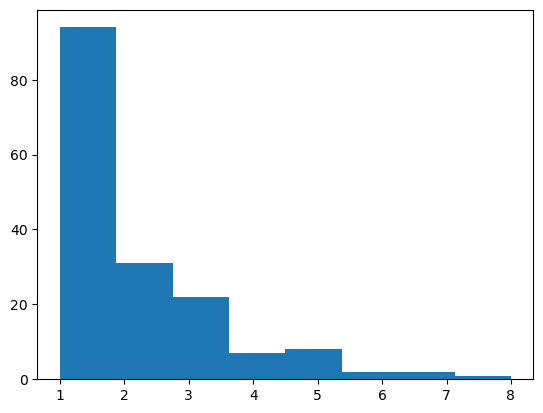

In [ ]:
# 👉 Agrupa el DataFrame por el campo repoId (cada repositorio).
# 👉 Cuenta cuántos registros (calificaciones) hay para cada repoId.
plt.hist(df_ratings.groupby(["repoId"])["repoId"].count(),bins=8)

# Método 1: User-Based

In [ ]:
# Ese bloque de código está construyendo una matriz usuario–item (muy típica en sistemas de recomendación).
df_matrix = pd.pivot_table(df_ratings, values='rating', index='userId', columns='repoId').fillna(0)
df_matrix

repoId,1,2,3,4,5,6,7,8,9,10,...,158,159,160,161,162,163,164,165,166,167
userId,,,,,,,,,,,,,,,,,,,,,
1,2.0,3.0,4.0,5.0,3.0,1.0,5.0,1.0,0.0,4.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


La tabla que estás viendo es exactamente la matriz usuario–item (user–repo) de la que hablamos recién.

👉 Interpretación clave:

Estructura

Filas = usuarios (userId de 1 a 30 en este caso).

Columnas = repositorios (repoId de 1 a 167).

Valores = calificación que ese usuario le dio a ese repositorio.

0.0 significa que el usuario no calificó ese repo.

Lo que refleja

El dataset es muy disperso (sparse): la mayoría de las celdas son 0.

Cada usuario solo calificó un puñado de repos, mientras que hay muchos repos sin calificación para él.

Esto es típico en sistemas de recomendación: los usuarios no interactúan con todos los ítems.

Ejemplo de lectura

Usuario 1: calificó varios repos (ej. repo 1 con 2.0, repo 4 con 5.0, repo 7 con 5.0, repo 10 con 4.0).

Usuario 3: solo calificó el repo 7 con 5.0.

Usuario 30: calificó varios repos con valores altos (ej. repo 3 con 4.0, repo 4 con 5.0, repo 7 con 5.0).

Implicancias para un recomendador

Puedes calcular similitudes entre usuarios (quiénes califican parecido) o entre repositorios (qué repos son valorados por usuarios similares).

La escasez de datos obliga a usar técnicas como filtrado colaborativo, factorización matricial (SVD) o embeddings para poder predecir ratings faltantes.

Ejemplo: si el usuario 3 solo calificó un repo, el sistema intentará recomendarle otros basándose en usuarios que también valoraron ese repo.

📌 En conclusión:
Esta matriz es la base sobre la que un sistema de recomendación aprende patrones de preferencia. La dispersión que ves (muchos 0.0) es un desafío común y por eso se aplican algoritmos especializados para rellenar esas “lagunas” con predicciones.

In [14]:
ratings = df_matrix.values
ratings.shape

(30, 167)

In [ ]:
# 👉 Convierte el DataFrame df_matrix en un array de NumPyratings = df_matrix.values
sparsity = float(len(ratings.nonzero()[0]))
sparsity /= (ratings.shape[0] * ratings.shape[1])
sparsity *= 100
print(f'Sparsity: {round(sparsity,2)}%')
# 👉 Muestra en pantalla el porcentaje de celdas ocupadas (ratings existentes) respecto al total posible.

Sparsity: 6.43%


In [16]:
float(len(ratings.nonzero()[0]))

322.0

In [17]:
ratings_train, ratings_test = train_test_split(ratings, test_size = 0.2, shuffle=False, random_state=42)

In [18]:
ratings_train.shape

(24, 167)

In [19]:
ratings_test.shape

(6, 167)

<ul>
<li>Matriz de similitud entre los usuarios (distancia del coseno -vectores-).</li>
<li>Predecir la valoración desconocida de un ítem i para un usuario activo u basandonos en la suma ponderada de todas las valoraciones del resto de usuarios para dicho ítem.</li>
<li>Recomendaremos los nuevos ítems a los usuarios según lo establecido en los pasos anteriores.</li>
</ul>

In [ ]:
# Construimos una matriz de similitud entre las filas de la matriz "ratings"
# Cada fila de "ratings" representa a un usuario (sus calificaciones sobre los repositorios)

# Paso 1: calculamos las distancias de coseno entre todas las filas (usuarios).
#   - La distancia de coseno mide cuán diferentes son dos vectores en cuanto a dirección.
#   - Si la distancia = 0 → son idénticos.
#   - Si la distancia = 1 → no tienen nada en común (ortogonales).
dist_matrix = sklearn.metrics.pairwise.cosine_distances(ratings)

# Paso 2: convertimos la "distancia" en "similitud".
#   - Similitud = 1 - Distancia
#   - Así, un valor cercano a 1 significa usuarios muy parecidos,
#     y un valor cercano a 0 significa usuarios muy distintos.
sim_matrix = 1 - dist_matrix

# Resultado: "sim_matrix" es una matriz cuadrada (n_usuarios × n_usuarios).
#   - Cada celda [i, j] indica cuán parecido es el usuario i al usuario j.
#   - La diagonal siempre vale 1 (todo usuario es idéntico consigo mismo).
#   - La matriz es simétrica: sim[i, j] = sim[j, i].
sim_matrix.shape

Esta matriz te dice qué tan parecidos son los usuarios en sus calificaciones.

Los valores altos (ej. >0.7) indican posibles vecinos cercanos (usuarios de referencia para recomendaciones).

Los valores bajos (~0 o ~0.1) indican que no vale la pena compararlos porque no tienen patrones de calificación similares.

In [22]:
sim_matrix

array([[1.        , 0.44336599, 0.49830328, 0.36802007, 0.24677596,
        0.        , 0.        , 0.11574818, 0.09821559, 0.12887454,
        0.        , 0.2648261 , 0.        , 0.06187576, 0.16527235,
        0.        , 0.2564571 , 0.        , 0.18734552, 0.09516725,
        0.48917543, 0.17318984, 0.03772565, 0.49609349, 0.15436059,
        0.30893011, 0.10339378, 0.        , 0.16295172, 0.51682627],
       [0.44336599, 1.        , 0.73881135, 0.49750116, 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.36858386, 0.        , 0.        , 0.73553501, 0.        ,
        0.66558424, 0.        , 0.        , 0.        , 0.41674581],
       [0.49830328, 0.73881135, 1.        , 0.535097  , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.

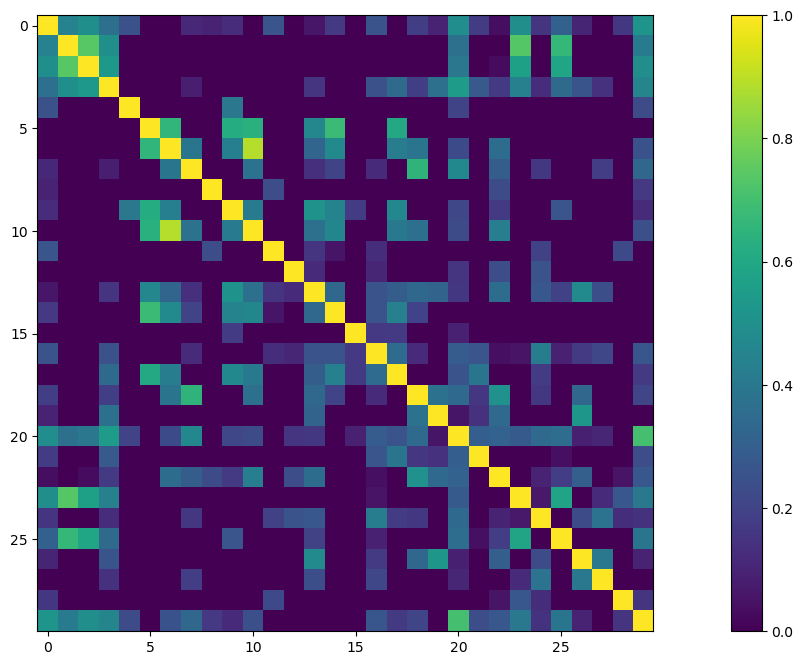

In [23]:
plt.rcParams['figure.figsize'] = (20.0, 8.0)
plt.imshow(sim_matrix);
plt.colorbar()
plt.show()

Este gráfico confirma que tu dataset es muy esparso y que solo algunos usuarios muestran similitudes relevantes.
Un recomendador colaborativo podría aprovechar esas similitudes para sugerir ítems (repos) de los usuarios verdes/amarillos, pero tendría que manejar los violetas (similitud casi nula) con técnicas adicionales (ej. factorización matricial, embeddings).

In [ ]:
#separar las filas y columnas de train y test
# 👉 Toma las primeras 24 filas y 24 columnas de la matriz de similitud.
sim_matrix_train = sim_matrix[0:24,0:24]
sim_matrix_test = sim_matrix[24:30,24:30]
print(sim_matrix_train.shape)
print(sim_matrix_test.shape)

(24, 24)
(6, 6)


## Predicciones (las recomendaciones!)

In [ ]:
# 📌 Interpretación final:
# Ahora tenés una matriz de predicciones:

# Filas = usuarios (train).
# Columnas = repositorios.
# Valores = rating estimado (aunque el usuario no lo haya dado).

users_predictions = sim_matrix_train.dot(ratings_train) / np.array([np.abs(sim_matrix_train).sum(axis=1)]).T

In [26]:
users_predictions.shape

(24, 167)

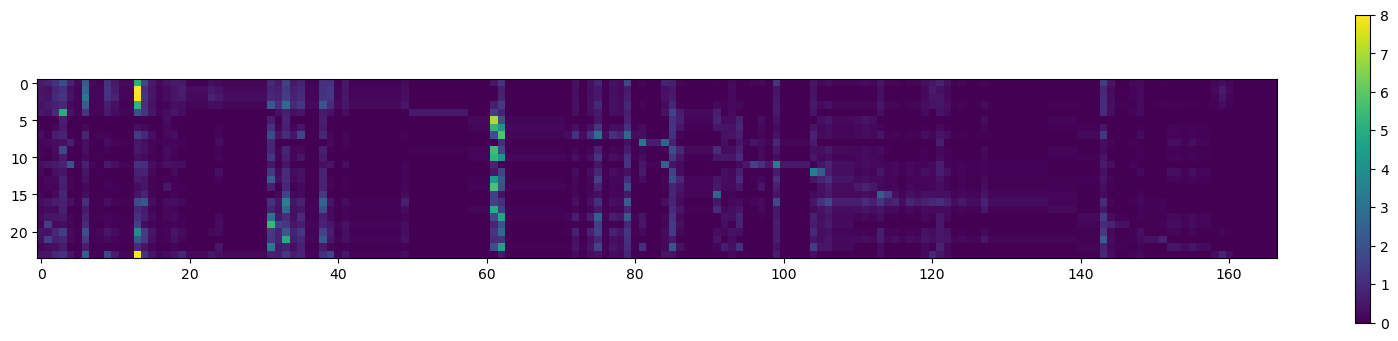

In [27]:
plt.rcParams['figure.figsize'] = (20.0, 4.0)
plt.imshow(users_predictions);
plt.colorbar()
plt.show()

### Veamos un ejemplo

In [ ]:
USUARIO_EJEMPLO = 'jbagnato' # debe existir en nuestro dataset de train!
data = df_users[df_users['username'] == USUARIO_EJEMPLO]
usuario_ver = data.iloc[0]['userId'] -1 # resta 1 para obtener el index de pandas
user0=users_predictions.argsort()[usuario_ver]

# Veamos los tres recomendados con mayor puntaje en la predic para este usuario
for i, aRepo in enumerate(user0[-3:]):
    selRepo = df_repos[df_repos['repoId']==(aRepo+1)]
    print(selRepo['title'] , 'puntaje:', users_predictions[usuario_ver][aRepo])
    
# Este código recomienda al usuario "jbagnato" los 3 repositorios que, según tu modelo 
# de similitud de usuarios, tienen mayor probabilidad de interesarle (mayor rating predicho).

4    ytdl-org / youtube-dl
Name: title, dtype: object puntaje: 2.061791042203265
84    dipanjanS / practical-machine-learning-with-py...
Name: title, dtype: object puntaje: 2.4496166855518746
99    abhat222 / Data-Science--Cheat-Sheet
Name: title, dtype: object puntaje: 3.362878201910944


## Medir el Error

In [ ]:
def get_mse(preds, actuals):
    if preds.shape[1] != actuals.shape[1]:
        actuals = actuals.T
    preds = preds[actuals.nonzero()].flatten()
    actuals = actuals[actuals.nonzero()].flatten()
    return mean_squared_error(preds, actuals)

# te dice qué tan bien tu modelo de filtrado colaborativo está prediciendo los ratings verdaderos en el set de prueba.

In [30]:
get_mse(users_predictions, ratings_train)

3.3906497514974663

Un MSE de ~3.39 significa que, en promedio, el error cuadrático es 3.39

O sea, en promedio el modelo se equivoca por casi 2 puntos de rating.

In [31]:
# Realizo las predicciones para el test set
users_predictions_test = sim_matrix.dot(ratings) / np.array([np.abs(sim_matrix).sum(axis=1)]).T
users_predictions_test = users_predictions_test[24:30,:]

get_mse(users_predictions_test, ratings_test)

4.722040854666231

Interpretación:

Comparado con el train (3.39)

RMSE ≈ √4.72 ≈ 2.17

El error subió al evaluar en test → típico cuando el modelo generaliza peor fuera de los datos de entrenamiento.

Indica que tu filtrado colaborativo usuario–usuario sobreajustó un poco a los usuarios de train, y al pasar a test pierde precisión.

📌 Conclusión:
El modelo está funcionando, pero la métrica indica que no predice demasiado bien en test. Es esperable en datasets muy dispersos y con filtrado colaborativo básico.

# Método 2: Usando Nearest Neighbors

In [32]:
k = 8
neighbors = NearestNeighbors(n_neighbors=k, metric='cosine')
neighbors.fit(ratings_train)

,n_neighbors,8
,radius,1.0
,algorithm,'auto'
,leaf_size,30
,metric,'cosine'
,p,2
,metric_params,None
,n_jobs,None


In [33]:
top_k_distances, top_k_users = neighbors.kneighbors(ratings_train, return_distance=True)
top_k_distances.shape

(24, 8)

📌 Interpretación:
Ahora tenés listo un buscador de vecinos. Con este objeto (neighbors) podés:

Encontrar los usuarios más parecidos a un usuario dado.

Usar esos vecinos para predecir ratings o recomendar repos.

In [ ]:
top_k_distances[usuario_ver] #jbagnato

array([0.        , 0.7351739 , 0.76208452, 0.8501134 , 0.86746954,
       0.94477898, 1.        , 1.        ])


Con esa info podés:
Ver qué tan parecido es el usuario a sus vecinos.


### Primer valor = 0.0

Siempre aparece porque el primer “vecino” es el propio usuario.

La distancia consigo mismo es 0 → similitud máxima (1).

### Valores intermedios (0.73 – 0.94)

Distancias a otros usuarios.

Mientras más baja, más parecido.

Por ejemplo:

0.735 significa que la similitud de coseno ≈ 1 - 0.735 = 0.265 (baja).

0.762 → similitud ≈ 0.238.

0.850 → similitud ≈ 0.150.

Esto muestra que tus usuarios no son muy parecidos entre sí → las similitudes son bajas (máx ~0.26).

### Valores 1.0

Distancia máxima → significa que son completamente ortogonales (no tienen nada en común en sus calificaciones).

O sea, no comparten repos calificados o sus ratings no se solapan.

In [35]:
top_k_users.shape

(24, 8)

In [ ]:
res = top_k_users[usuario_ver] #jbagnato
res
# 👉 Lo que devuelve es un array con los índices de los k vecinos más cercanos al usuario elegido (usuario_ver).

array([11,  0,  8, 13, 16, 14, 18, 22])

In [37]:
for a_index in res:
    print(df_users[df_users['userId'] == (a_index+1)])

    userId  username                  name
11      12  jbagnato  Juan Ignacio Bagnato
   userId  username                  name
0       1  iris9112  Isabel Ruiz Buriticá
   userId      username         name
8       9  camiloyate09  Camilo Yate
    userId   username    name
13      14  aguadotzn  Adrián
    userId     username                    name
16      17  carlosevi94  Carlos Sevilla Barceló
    userId       username           name
14      15  sjvasconcello  sjvasconcello
    userId     username          name
18      19  marisbotero  Maris Botero
    userId  username        name
22      23  kevin11h  Kevin Hung


In [ ]:
users_predicts_k = np.zeros(ratings_train.shape)

for i in range(ratings_train.shape[0]):# para cada usuario del conjunto de entrenamiento
    users_predicts_k[i,:] = top_k_distances[i].T.dot(ratings_train[top_k_users][i]) / np.array([np.abs(top_k_distances[i].T).sum(axis=0)]).T
    
# Bien, acá lo que intentás armar es una matriz de predicciones de ratings usando 
# solo los k vecinos más cercanos (en vez de todos los usuarios como en la versión anterior).

In [39]:
users_predicts_k.shape

(24, 167)

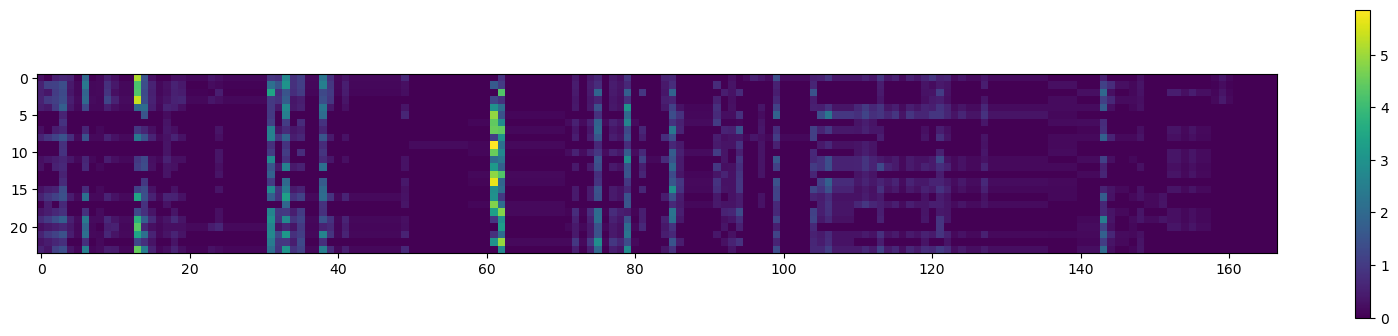

In [40]:
plt.imshow(users_predicts_k);
plt.colorbar()
plt.show()

In [ ]:
user0=users_predicts_k.argsort()[usuario_ver][-4:]
# los tres con mayor puntaje en la predic para este usuario
# agrego 4 puesto que uno es mi propio repositorio
for aRepo in user0:
    selRepo = df_repos[df_repos['repoId'] == (aRepo+1)]
    print(selRepo['title'], 'puntaje:', users_predicts_k[usuario_ver][aRepo])

# Esto imprime el Top-3 de repositorios recomendados al usuario (más uno que descartás porque puede ser suyo), según el modelo de k-vecinos.

61    jbagnato / machine-learning
Name: title, dtype: object puntaje: 2.0397761420377654
62    tensorflow / tensorflow
Name: title, dtype: object puntaje: 2.2728673580549694
31    freeCodeCamp / freeCodeCamp
Name: title, dtype: object puntaje: 2.7762555883083695
79    jakevdp / PythonDataScienceHandbook
Name: title, dtype: object puntaje: 2.879578790241746


In [42]:
get_mse(users_predicts_k, ratings_train)

5.7944864954921425

📌 Interpretación:

Comparación con antes

Con todos los usuarios (similaridad completa) en train → MSE ≈ 3.39.

Con solo k=8 vecinos → MSE ≈ 5.79.
⟶ Es decir, al restringirte a pocos vecinos, el error aumentó.

Qué significa

El modelo de k-vecinos está siendo menos preciso en train que el de similitud global.

Esto puede pasar porque:

Tus usuarios no tienen suficientes ratings en común (alta sparsity).

Con k=8 te estás quedando corto y no hay vecinos “fuertes”.

La similitud promedio entre usuarios era baja (ya lo viste: distancias ~0.73–0.94 → similitudes muy débiles).

In [43]:
get_mse(users_predicts_k, ratings_test)

10.727470808481653

La conclusión es clara 👇

Tu modelo user-based kNN con k=8 vecinos no está funcionando bien:

En train el error ya era alto (MSE ≈ 5.79, RMSE ≈ 2.4).

En test el error se disparó (MSE ≈ 10.73, RMSE ≈ 3.3).

Esto significa que no logra generalizar: las predicciones para usuarios de test se alejan demasiado de los ratings reales.

📌 Las causas principales son:

La matriz es muy dispersa (pocos ratings por usuario).

Los usuarios son poco similares entre sí.

Usar pocos vecinos (k=8) empeora la situación.

# Método 3: Collaborative Filtering Basado en Items

In [44]:
#basado en items
n_repos = ratings_train.shape[1]
n_repos

167

In [45]:
neighbors = NearestNeighbors(n_neighbors=n_repos, metric='cosine')
neighbors.fit(ratings_train.T)

,n_neighbors,167
,radius,1.0
,algorithm,'auto'
,leaf_size,30
,metric,'cosine'
,p,2
,metric_params,None
,n_jobs,None


📌 Interpretación:
Ahora tenés un motor de similitud item–item. Con él podés:

Consultar qué repos son los más similares entre sí.

Usar esas relaciones para recomendar a un usuario repos similares a los que ya valoró positivamente.

In [46]:
top_k_distances, top_k_items = neighbors.kneighbors(ratings_train.T, return_distance=True)
top_k_distances.shape

(167, 167)

📌 Interpretación:
Ahora tenés una matriz completa de distancias item–item:

Cada fila = un repo.

Cada fila contiene las distancias a todos los demás repos, ordenados de más parecido a menos.

El primer vecino siempre es el mismo repo, con distancia 0.

In [47]:
top_k_items.shape

(167, 167)

In [48]:
top_k_items

array([[  0,  15,  18, ...,  60,  58, 166],
       [  1, 144, 145, ...,  73,  67, 166],
       [  0,  15,  18, ...,  60,  58, 166],
       ...,
       [  0, 106, 107, ...,  59,  61, 166],
       [  0, 106, 107, ...,  59,  61, 166],
       [  0, 106, 107, ...,  59,  61, 166]])

In [49]:
data = df_repos[df_repos['title'] == 'jbagnato / machine-learning']
repo_ver = data.iloc[0]['repoId'] -1
repo_ver

61

lo que hiciste acá fue elegir un repositorio específico (en este caso "jbagnato / machine-learning") y obtener su índice para usarlo dentro de la matriz item–item.

In [50]:
df_repos[df_repos['repoId'].isin([repo_ver+1])]

,repoId,title,categories,stars
61,62,jbagnato / machine-learning,"Código Python, Jupyter Notebooks, archivos csv...",48.0


In [51]:
item_preds = ratings_train.dot(top_k_distances) / np.array([np.abs(top_k_distances).sum(axis=1)])

📌 Interpretación final:
item_preds es tu matriz de predicciones item–item.

Filas = usuarios.

Columnas = repositorios.

Valores = rating estimado que ese usuario daría a ese repo.

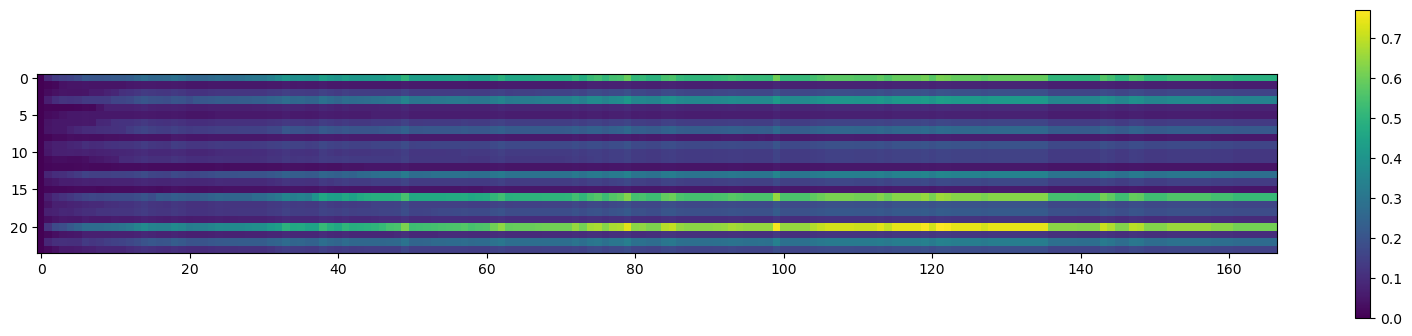

In [52]:
plt.imshow(item_preds);
plt.colorbar()
plt.show()

In [53]:
user0=item_preds.argsort()[usuario_ver]
user0

# los tres con mayor puntaje en la predic para este usuario
for aRepo in user0[-3:]:
    selRepo = df_repos[df_repos['repoId']==(aRepo+1)]
    print(selRepo['title'], 'puntaje:', item_preds[usuario_ver][aRepo])

119    donnemartin / data-science-ipython-notebooks
Name: title, dtype: object puntaje: 0.15701711431739965
122    start
Name: title, dtype: object puntaje: 0.15701711431739965
121    datasciencemasters / go
Name: title, dtype: object puntaje: 0.1587462822190084


In [54]:
get_mse(item_preds, ratings_train)

10.358710723721423

In [55]:
get_mse(item_preds, ratings_test)

14.05563947597318

# Método 4: recomendación por Correlación

In [ ]:
# calcular promedio de rating por repo
average_rating = pd.DataFrame(df_ratings.groupby('repoId')['rating'].mean())

# agregar la cantidad de ratings por repo
average_rating['ratingCount'] = pd.DataFrame(df_ratings.groupby('repoId')['rating'].count())

# ver los repos con más calificaciones
average_rating.sort_values('ratingCount', ascending=False).head()

# vector de ratings de mi repo (id 62 en la matriz, repoId=63 en df)
mi_repo_ratings = df_matrix[62]

# correlación de Pearson entre mi repo y todos los demás repos
similar_to_mine = df_matrix.corrwith(mi_repo_ratings)

# pasar a DataFrame y quitar valores NaN
corr_mine = pd.DataFrame(similar_to_mine, columns=['pearsonR'])
corr_mine.dropna(inplace=True)

# unir correlación con rating promedio de cada repo
corr_summary = corr_mine.join(average_rating['rating'])

# filtrar repos con al menos 1 rating y ordenar por mayor similitud
corr_summary[corr_summary['rating']>=1].sort_values('pearsonR', ascending=False).head(10)



,pearsonR,rating
repoId,,
62,1.000000,7.0
87,0.341515,3.0
92,0.341515,3.0
95,0.341515,3.0
139,0.336601,1.0
138,0.336601,1.0
137,0.336601,1.0
140,0.336601,1.0
88,0.336601,1.0


In [57]:
# Veamos uno de los recomendados
df_repos[df_repos['repoId'] == 92]

,repoId,title,categories,stars
91,92,joanby / python-ml-course,Curso de Introducción a Machine Learning con P...,156.0


# Método 5: Repo más popular -sin collaborative filtering-

Esta es la manera básica y sin uso de machine learning de ofrecer recomendaciones. <br>
estas no serán personalizadas, serán iguales para cualquier usuario

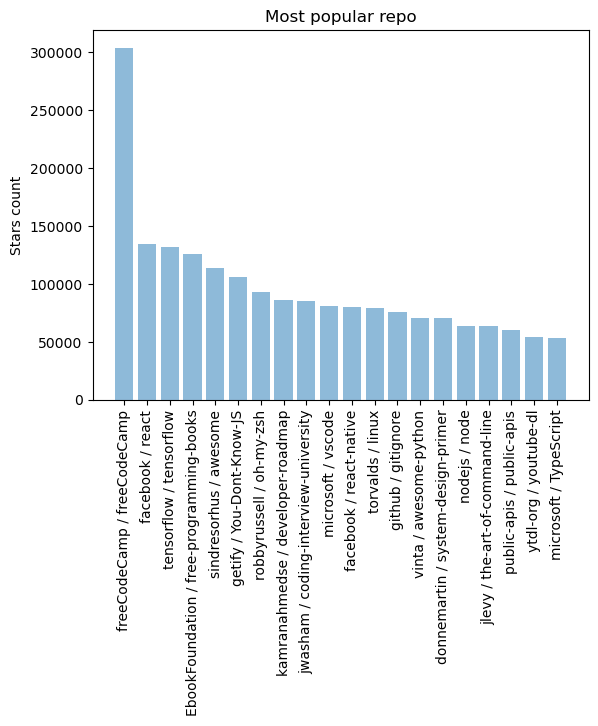

In [ ]:
# agrupa los repos por cantidad de 'stars' y suma títulos asociados
popular_repo = df_repos[['title','stars']].groupby('stars').sum().reset_index()

# ordena por 'stars' de mayor a menor y toma los 20 primeros
popular_repo_top_20 = popular_repo.sort_values('stars', ascending=False).head(n=20)

# resetea configuración gráfica
plt.rcdefaults()

# lista de títulos de los repos
objects = (list(popular_repo_top_20['title']))

# posiciones para las barras (0, 1, 2, ...)
y_pos = np.arange(len(objects))

# valores de 'stars' para cada repo
performance = list(popular_repo_top_20['stars'])

# dibuja las barras
plt.bar(y_pos, performance, align='center', alpha=0.5)

# pone los nombres de los repos en el eje X
plt.xticks(y_pos, objects, rotation='vertical')

# etiquetas de los ejes y título
plt.ylabel('Stars count')
plt.title('Most popular repo')

# muestra el gráfico
plt.show()
